<a href="https://colab.research.google.com/github/yogitaalone04-web/machine-learning-practicals/blob/main/Week7_SVM_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CS24D017: Yogita Alone

AIM: To apply Support Vector Machine for classification and analyze the impact of different kernels on model accuracy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
path="/content/drive/MyDrive/ML_Dataset/pulsar_stars.csv"
df=pd.read_csv(path)
df.head(5)

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [5]:
print(df.head())

    Mean of the integrated profile  \
0                       140.562500   
1                       102.507812   
2                       103.015625   
3                       136.750000   
4                        88.726562   

    Standard deviation of the integrated profile  \
0                                      55.683782   
1                                      58.882430   
2                                      39.341649   
3                                      57.178449   
4                                      40.672225   

    Excess kurtosis of the integrated profile  \
0                                   -0.234571   
1                                    0.465318   
2                                    0.323328   
3                                   -0.068415   
4                                    0.600866   

    Skewness of the integrated profile   Mean of the DM-SNR curve  \
0                            -0.699648                   3.199833   
1                        

In [6]:
# Define features (X) and target (y)
X = df.drop(columns=['target_class'])  # Drop the target column (we don't use it in features)
y = df['target_class']  # Target column

In [7]:
# Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
# Standardize the features (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [9]:
# Initialize the SVM classifier with a linear kernel
svm = SVC(kernel='linear', random_state=42)

In [10]:
# Display the first 5 rows to check the current column names
print("Original Column Names:")
print(df.columns)

Original Column Names:
Index([' Mean of the integrated profile',
       ' Standard deviation of the integrated profile',
       ' Excess kurtosis of the integrated profile',
       ' Skewness of the integrated profile', ' Mean of the DM-SNR curve',
       ' Standard deviation of the DM-SNR curve',
       ' Excess kurtosis of the DM-SNR curve', ' Skewness of the DM-SNR curve',
       'target_class'],
      dtype='object')


In [11]:
# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

In [12]:
# Display the cleaned column names
print("\nCleaned Column Names:")
print(df.columns)


Cleaned Column Names:
Index(['Mean of the integrated profile',
       'Standard deviation of the integrated profile',
       'Excess kurtosis of the integrated profile',
       'Skewness of the integrated profile', 'Mean of the DM-SNR curve',
       'Standard deviation of the DM-SNR curve',
       'Excess kurtosis of the DM-SNR curve', 'Skewness of the DM-SNR curve',
       'target_class'],
      dtype='object')


In [13]:
# Rename the columns (optional, but to make them more descriptive)
df.rename(columns={
    'Mean of the integrated profile': 'Mean_integrated_profile',
    'Standard deviation of the integrated profile': 'Std_integrated_profile',
    'Excess kurtosis of the integrated profile': 'Excess_kurtosis_integrated',
    'Skewness of the integrated profile': 'Skewness_integrated',
    'Mean of the DM-SNR curve': 'Mean_DM_SNR_curve',
    'Standard deviation of the DM-SNR curve': 'Std_DM_SNR_curve',
    'Excess kurtosis of the DM-SNR curve': 'Excess_kurtosis_DM_SNR',
    'Skewness of the DM-SNR curve': 'Skewness_DM_SNR',
    'target_class': 'Target_class'
}, inplace=True)

In [14]:
print("\nRenamed Column Names:")
print(df.columns)


Renamed Column Names:
Index(['Mean_integrated_profile', 'Std_integrated_profile',
       'Excess_kurtosis_integrated', 'Skewness_integrated',
       'Mean_DM_SNR_curve', 'Std_DM_SNR_curve', 'Excess_kurtosis_DM_SNR',
       'Skewness_DM_SNR', 'Target_class'],
      dtype='object')


In [15]:
# Define features (X) and target (y)
X = df.drop(columns=['Target_class'])  # Drop the target column (we don't use it in features)
y = df['Target_class']  # Target column

In [16]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc=SVC()
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
print('Model accuracy score with default hyperparameters:{0:0.4f}'.format(accuracy_score(y_test,y_pred)))

Model accuracy score with default hyperparameters:0.9728


In [17]:
svc=SVC(kernel='linear')
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)

In [18]:
from sklearn.metrics import confusion_matrix, classification_report

In [19]:
y_true = [0, 1, 1, 0, 1, 0, 1, 1, 0, 0]  # Actual values
y_pred = [0, 1, 0, 0, 1, 1, 1, 1, 0, 1]

In [20]:
# 1. Generate the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

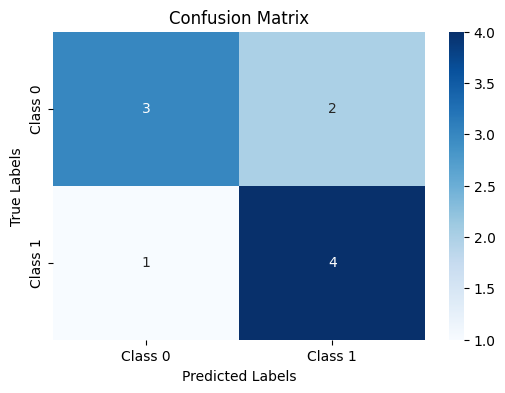

In [21]:
# 2. Plot the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [22]:
report = classification_report(y_true, y_pred)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.67      0.80      0.73         5

    accuracy                           0.70        10
   macro avg       0.71      0.70      0.70        10
weighted avg       0.71      0.70      0.70        10



In [23]:
#Accuraccy
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report

In [24]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc=SVC(C=1000.0)
svc.fit(X_train,y_train)
y_pred=svc.predict(X_test)
print('Model accuracy score with default hyperparameters:{0:0.4f}'.format(accuracy_score(y_test,y_pred)))

Model accuracy score with default hyperparameters:0.9786


In [25]:
poly_svc=SVC(kernel='poly',C=1.0)
poly_svc.fit(X_train,y_train)
y_pred=poly_svc.predict(X_test)

In [26]:
sigmoid_svc=SVC(kernel='sigmoid',C=1.0)
sigmoid_svc.fit(X_train,y_train)
y_pred=sigmoid_svc.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.9243947858472998


In [28]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

sigmoid_svc100 = SVC(kernel='sigmoid', C=100.0)

# Correct training
sigmoid_svc100.fit(X_train, y_train)

# Prediction
y_pred = sigmoid_svc100.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9208566108007449


In [29]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[4675  209]
 [ 216  270]]


In [30]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      4884
           1       0.56      0.56      0.56       486

    accuracy                           0.92      5370
   macro avg       0.76      0.76      0.76      5370
weighted avg       0.92      0.92      0.92      5370



In [37]:
# Apply SVM with Different Kernels

kernels = ['linear', 'poly', 'rbf', 'sigmoid']

results = {}   # VERY IMPORTANT

for kernel in kernels:

    print("\n=================================")
    print("SVM with", kernel.upper(), "Kernel")
    print("=================================")

    model = SVC(kernel=kernel, C=1.0)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results[kernel] = acc   # Store accuracy

    print("Accuracy:", acc)


# Final Comparison
print("\n====== Kernel Comparison ======")
for k, v in results.items():
    print(f"{k.upper()} Kernel Accuracy: {v}")


SVM with LINEAR Kernel
Accuracy: 0.978584729981378

SVM with POLY Kernel
Accuracy: 0.97243947858473

SVM with RBF Kernel
Accuracy: 0.9728119180633147

SVM with SIGMOID Kernel
Accuracy: 0.9243947858472998

====== Kernel Comparison ======
LINEAR Kernel Accuracy: 0.978584729981378
POLY Kernel Accuracy: 0.97243947858473
RBF Kernel Accuracy: 0.9728119180633147
SIGMOID Kernel Accuracy: 0.9243947858472998
